In [1]:
import numpy as np
import matplotlib.pyplot as plt

def exact_sol(t):
    return 3 - 0.998 * np.exp(-1000 * t) - 2.002 * np.exp(-t)

def forward_euler(h, t_end):
    t_values = np.arange(0, t_end + h, h)
    y_values = np.zeros(len(t_values))
    y_values[0] = 0  # Initial condition
    
    for i in range(len(t_values) - 1):
        slope = -1000 * y_values[i] + 3000 - 2000 * np.exp(-t_values[i])
        y_values[i+1] = y_values[i] + h * slope
        
        if abs(y_values[i+1]) > 1e5:
            return t_values[:i+2], y_values[:i+2]
            
    return t_values, y_values
def forward_euler_efficient(h, t_end):
    t = 0
    y = 0
    t_list = [t]
    y_list = [y]
    
    save_interval = max(1, int(0.01 / h)) 
    
    steps = int(t_end / h)
    for i in range(1, steps + 1):
        slope = -1000 * y + 3000 - 2000 * np.exp(-t)
        y = y + h * slope
        t = i * h
        
        if i % save_interval == 0:
            t_list.append(t)
            y_list.append(y)
            
        if abs(y) > 1e5: # Stability check
            break
            
    return np.array(t_list), np.array(y_list)

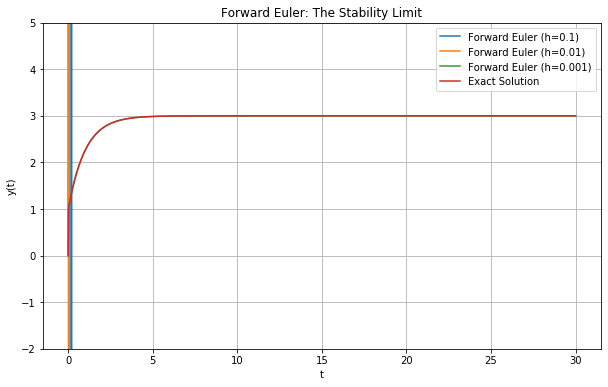

In [2]:
#Parameters
h_list = [0.1, 0.01, 0.001]
t_end = 30

plt.figure(figsize=(10, 6))

for h in h_list:
    t, y = forward_euler(h, t_end)
    plt.plot(t, y, label=f'Forward Euler (h={h})')

#Plotting
t_exact = np.linspace(0, 30, 1000)
plt.plot(t_exact, exact_sol(t_exact), label='Exact Solution')

#Graphing
plt.ylim(-2, 5)
plt.title("Forward Euler: The Stability Limit")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()

Used AI tool, Google Gemini to check code and look into more effecient ways of running the euler's forward to get the lower step sizes without error.

In [ ]:
h_list = [.1, .01, .001, .00001, .0000001]
t_end = 30

plt.figure(figsize=(10, 6))

for h in h_list:
    t, y = forward_euler_efficient(h, t_end)
    plt.plot(t, y, label=f'Forward Euler (h={h})')

t_exact = np.linspace(0, 30, 100)
plt.plot(t_exact, exact_sol(t_exact), label='Exact Solution')

plt.ylim(-2, 5)
plt.title("Forward Euler: The Stability Limit")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()